<a href="https://colab.research.google.com/github/suryansh24-coder/Machine-Learning-Journey/blob/main/KNN_Imputer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

In [6]:
df = pd.read_csv("train_new.csv")[['Age','Pclass','Fare','Survived']]

In [7]:
df.head()

,Age,Pclass,Fare,Survived
0,22.0,3,7.2500,0
1,38.0,1,71.2833,1
2,26.0,3,7.9250,1
3,35.0,1,53.1000,1
4,35.0,3,8.0500,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Pclass    891 non-null    int64  
 2   Fare      891 non-null    float64
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [9]:
df.isnull().mean()*100

,0
Age,19.86532
Pclass,0.00000
Fare,0.00000
Survived,0.00000


In [10]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [11]:
X_train ,X_test ,y_train ,y_test = train_test_split(X,y,test_size=0.2 , random_state=2)

In [12]:
X_train.head()

,Age,Pclass,Fare
30,40.0,1,27.7208
10,4.0,3,16.7000
873,47.0,3,9.0000
182,9.0,3,31.3875
876,20.0,3,9.8458


In [26]:
from scipy.spatial import distance
knn = KNNImputer(n_neighbors=5 , weights='distance')

X_train_trf = knn.fit_transform(X_train)
X_test_trf = knn.transform(X_test)

In [27]:
pd.DataFrame(X_train_trf , columns=X_train.columns)

,Age,Pclass,Fare
0,40.000000,1.0,27.7208
1,4.000000,3.0,16.7000
2,47.000000,3.0,9.0000
3,9.000000,3.0,31.3875
4,20.000000,3.0,9.8458
...,...,...,...
707,30.000000,3.0,8.6625
708,25.047962,3.0,8.7125
709,71.000000,1.0,49.5042
710,29.530076,1.0,221.7792


In [28]:
lr = LogisticRegression()

lr.fit(X_train_trf,y_train )
y_pred = lr.predict(X_test_trf)
accuracy_score(y_test,y_pred)

0.7039106145251397

In [29]:
si = SimpleImputer()
X_train_trf2 = si.fit_transform(X_train)
X_test_trf2 =  si.transform(X_test)

In [31]:
lr = LogisticRegression()

lr.fit(X_train_trf2 ,y_train)
y_pred2 = lr.predict(X_test_trf2)

accuracy_score(y_test,y_pred2)

0.6927374301675978

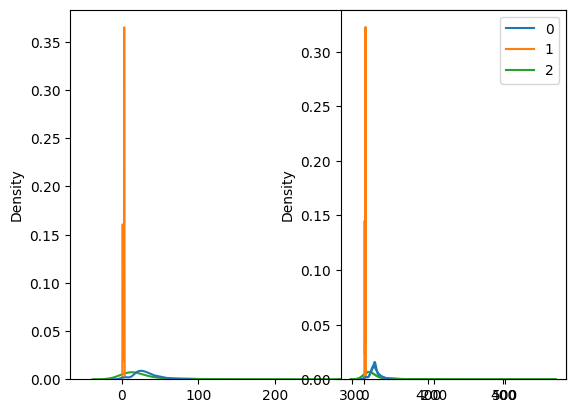

In [46]:
# 'Age','Pclass','Fare','Survived'
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(X)

plt.subplot(122)
sns.kdeplot(X_train_trf)
sns.kdeplot(X_train_trf2)
plt.show()

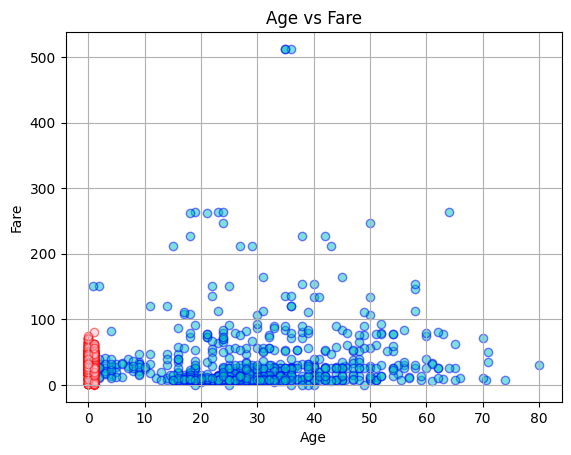

In [68]:
plt.scatter(X['Age'] , X['Fare'] , color='c' , alpha=0.5 , edgecolors='blue')
plt.scatter(y , X['Age'] , color='pink' , alpha=0.5 , edgecolors='red')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.grid(True)
plt.title('Age vs Fare')
plt.show()

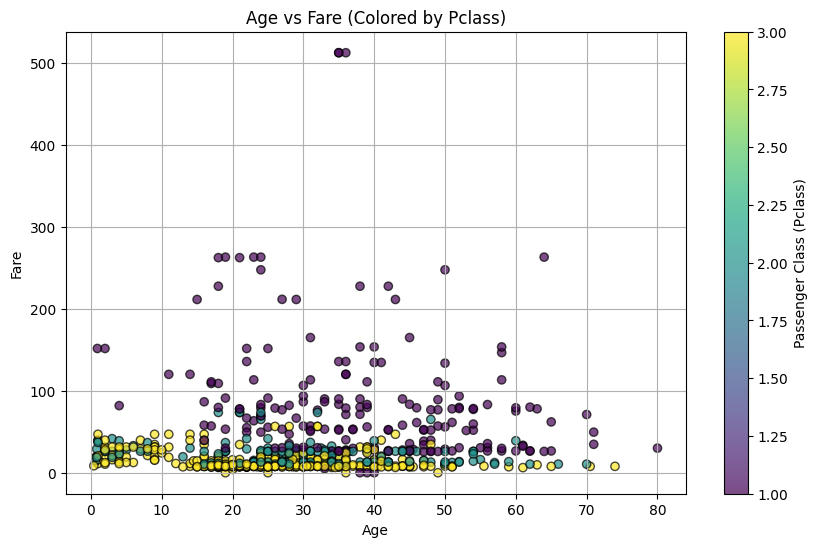

In [70]:
plt.figure(figsize=(10, 6))
scatter_plot = plt.scatter(X['Age'], X['Fare'], c=X['Pclass'], cmap='viridis', alpha=0.7, edgecolors='black')

plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare (Colored by Pclass)')
plt.grid(True)

# Now, pass the 'scatter_plot' object to colorbar
cbar = plt.colorbar(scatter_plot)
cbar.set_label('Passenger Class (Pclass)')

plt.show()


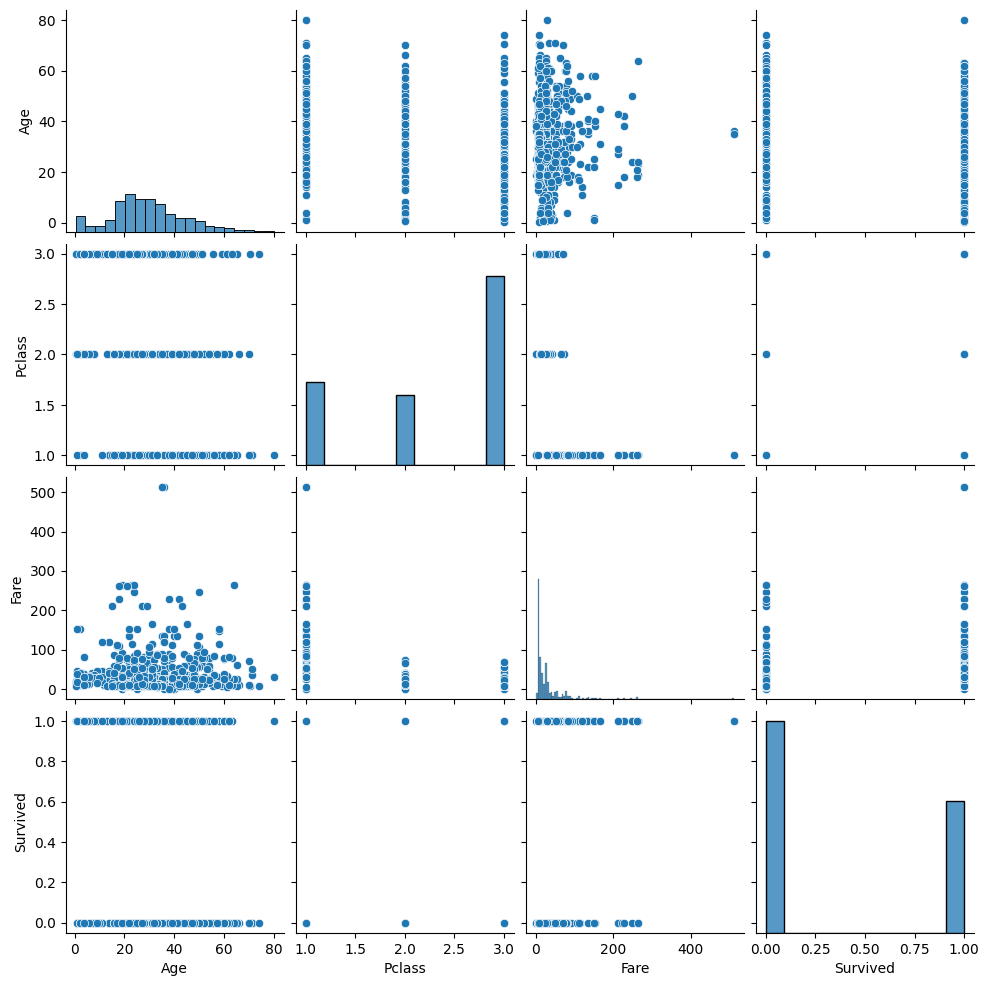

In [72]:
sns.pairplot(df)

<Axes: >

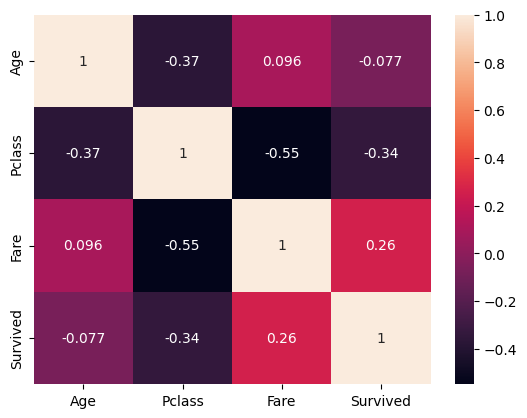

In [73]:
sns.heatmap(df.corr() , annot=True)